Connected to database successfully.
Fetched 244 rows from the database.
Data cleaned successfully.


C:\Users\user\AppData\Local\Temp\ipykernel_52444\964804314.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql(query, conn)
C:\Users\user\AppData\Local\Temp\ipykernel_52444\964804314.py:69: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[column].fillna(data[column].mean(), inplace=True)
C:\Users\user\AppData\Roaming\Python\Python39\site-packages\skle

Silhouette Score: 0.4601326751789529
Inertia: 309.96995122425454
   CUSTOMER_NUMBER  Total_Orders  Total_Ordered_Quantity    First_Order_Date  \
0              607           440                12264831 2021-10-11 07:27:40   
1              556             7                   89000 2021-10-22 09:37:28   
2               72           405                11473500 2021-10-13 04:58:34   
3              473             1                    7000 2022-08-26 18:41:03   
4              155           339                 9748100 2021-10-13 04:57:28   

      Last_Order_Date  Avg_Quantity_Per_Order  Order_Duration_Days  \
0 2024-05-20 18:07:13            27874.615909                  952   
1 2023-08-18 08:36:03            12714.285714                  664   
2 2024-05-20 07:10:14            28329.629630                  950   
3 2022-08-26 18:41:03             7000.000000                    0   
4 2024-05-19 08:00:50            28755.457227                  949   

   Order_Frequency  Cluster      

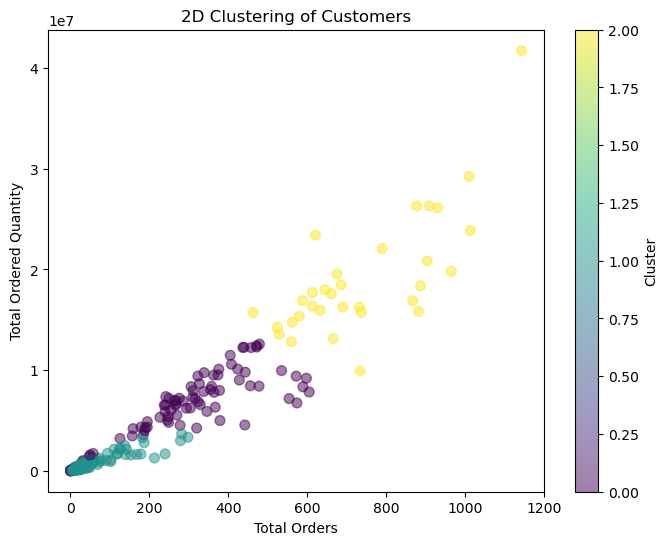

Connected to database successfully.
Table 'dim_classification_client' created successfully or already exists.
Data inserted into 'dim_classification_client' successfully.


In [1]:
import pyodbc
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Définir les informations de connexion
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Établir la connexion
try:
    connection = pyodbc.connect('DRIVER={SQL Server};SERVER='+server+';DATABASE='+database+';UID='+username+';PWD='+password)
    print("Connexion réussie à la base de données SQL Server")
    
    # Définir la requête SQL
    query = """
    SELECT f.ordered_quantity, r.start_time, r.product_group_code
    FROM fact_sales AS f
    INNER JOIN dim_order_recipe AS r ON f.FK_ORDER_RECIPE = r.pk_order_recipe
    WHERE r.product_group_code = 'DS' 
    """
    
    # Exécuter la requête SQL et récupérer les résultats dans un DataFrame pandas
    result = pd.read_sql(query, connection)
    
    # Convertir la colonne de dates en datetime
    result['start_time_date'] = pd.to_datetime(result['start_time'])
    
    # Définir la colonne 'start_time_date' comme index
    result.set_index('start_time_date', inplace=True)
    
    # Regrouper par mois et calculer la somme des quantités commandées pour chaque mois
    result = result.resample('M').sum(numeric_only=True).reset_index()
    
    # Afficher les résultats
    print("Résultats de la série temporelle regroupés par mois :")
    print(result)

except pyodbc.Error as e:
    print("Erreur lors de la connexion à la base de données SQL Server :", e)

# Convertir la colonne de dates en format de mois
result['month'] = result['start_time_date'].dt.to_period('M')

# Agréger les données par mois et calculer la somme de la quantité
monthly_sum = result.groupby('month')['ordered_quantity'].sum().reset_index()

# Stocker les sommes mensuelles dans un fichier CSV
monthly_sum.to_csv("monthly_sum_DS.csv", index=False)


# Lire le fichier CSV
df = pd.read_csv('monthly_sum_DS.csv')

# Convertir la colonne 'month' en format de date
df['month'] = pd.to_datetime(df['month'], format='%Y-%m')

# Ajouter 1 mois avant le premier mois dans le DataFrame
start_date = df['month'].min()
extra_months = pd.date_range(start=start_date - pd.DateOffset(months=1), periods=4, freq='M')
extra_data = pd.DataFrame({'month': extra_months, 'ordered_quantity': np.nan})
df = pd.concat([extra_data, df])



# Replace outliers
def replace_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 0.25 * IQR
    upper_bound = Q3 + 0.25 * IQR
    df[column] = df[column].apply(lambda x: x if (x >= lower_bound and x <= upper_bound) else np.nan)
    return df

df = replace_outliers(df, 'ordered_quantity')

# Compute median for each month
monthly_medians = df.groupby(df['month'].dt.month)['ordered_quantity'].median()

# Function to impute missing values based on month
def impute_missing_values_by_month(df, column):
    df[column] = df.apply(lambda row: monthly_medians[row['month'].month] if pd.isna(row[column]) else row[column], axis=1)
    return df

# Impute missing values
df = impute_missing_values_by_month(df, 'ordered_quantity')



# Enregistrer le DataFrame modifié dans un fichier CSV
df.to_csv('monthly_sum_DS_modified.csv', index=False)

print(df)

# Lire et afficher le fichier modifié
df = pd.read_csv('monthly_sum_DS_modified.csv', parse_dates=['month'], index_col=['month'])
df.head()


In [39]:

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


print("gaaaas")


df = pd.read_csv('monthly_sum_DS_modified.csv', parse_dates = ['month'], index_col = ['month'])
 
df.head()



    

gaaaas


,ordered_quantity
month,
2021-09-30,24392903.5
2021-10-31,24014853.5
2021-11-30,24335586.0
2021-12-31,25153799.0
2021-10-01,24014853.5


Statistiques ADF : -4.644549186944111
p-value : 0.00010683040097748028
Valeurs Critiques :
	1%: -3.639224104416853
	5%: -2.9512301791166293
	10%: -2.614446989619377


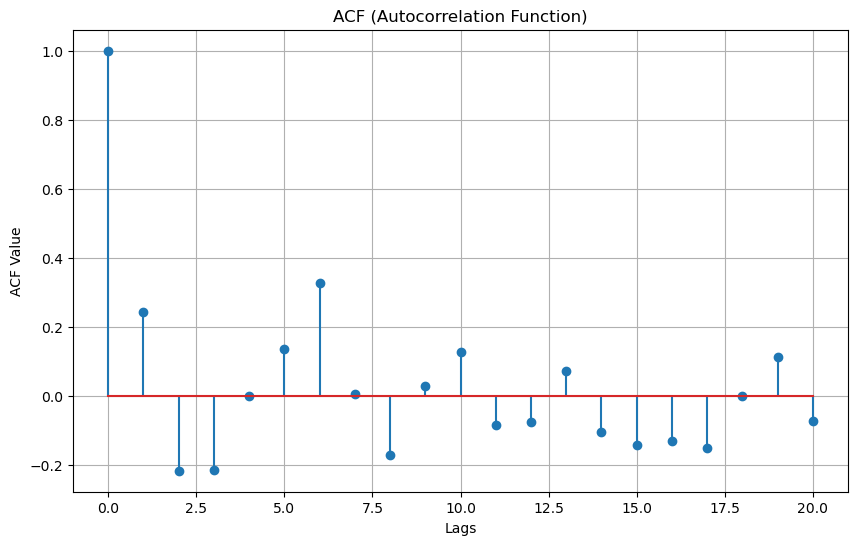

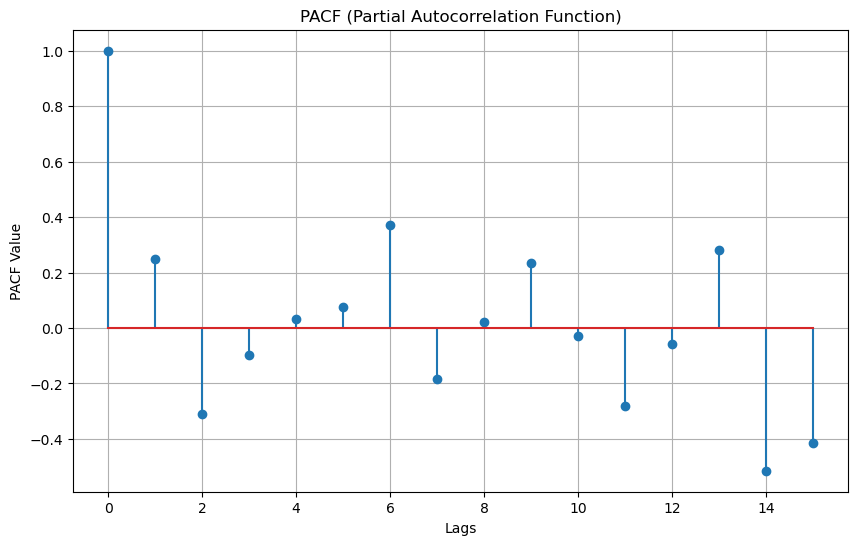

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf

# Vérification de la stationnarité avec le test ADF
result = adfuller(df['ordered_quantity'])

print('Statistiques ADF : {}'.format(result[0]))
print('p-value : {}'.format(result[1]))
print('Valeurs Critiques :')
for key, value in result[4].items():
    print('\t{}: {}'.format(key, value))

# Affichage de l'ACF (Autocorrelation Function)
acf_values = acf(df['ordered_quantity'], nlags=20)  # Ajustez nlags selon la taille de vos données

# Tracer l'ACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(acf_values)), acf_values, use_line_collection=True)
plt.title('ACF (Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('ACF Value')
plt.grid()
plt.show()

# Affichage de la PACF (Partial Autocorrelation Function)
# Ajustez nlags pour qu'il soit inférieur à 50 % de la taille de votre échantillon
pacf_values = pacf(df['ordered_quantity'], nlags=15)

# Tracer la PACF
plt.figure(figsize=(10, 6))
plt.stem(range(len(pacf_values)), pacf_values, use_line_collection=True)
plt.title('PACF (Partial Autocorrelation Function)')
plt.xlabel('Lags')
plt.ylabel('PACF Value')
plt.grid()
plt.show()


In [55]:
    
#############################log application ##########################

df_log = np.log(df)
df_log


,ordered_quantity
month,
2021-09-30,17.009803
2021-10-31,16.994183
2021-11-30,17.007450
2021-12-31,17.040519
2021-10-01,16.994183
2021-11-01,17.054078
2021-12-01,17.012341
2022-01-01,17.049068
2022-02-01,17.004076


MAE: 24900498.953083284
MSE: 620453547624164.4
RMSE: 24908904.986453425
R²: -4.2566370770623174e+17
                 Date      Forecast type
2023-11-01 2024-06-01  2.538029e+07   DS
2023-12-01 2024-07-01  2.598628e+07   DS
2024-01-01 2024-08-01  2.464687e+07   DS
2024-02-01 2024-09-01  2.389007e+07   DS
2024-03-01 2024-10-01  2.428527e+07   DS
2024-04-01 2024-11-01  2.499129e+07   DS
2024-05-01 2024-12-01  2.512353e+07   DS
2024-06-01 2025-01-01  2.474397e+07   DS
2024-07-01 2025-02-01  2.445755e+07   DS
2024-08-01 2025-03-01  2.453744e+07   DS
2024-09-01 2025-04-01  2.476263e+07   DS
2024-10-01 2025-05-01  2.483520e+07   DS
2024-11-01 2025-06-01  2.473175e+07   DS
2024-12-01 2025-07-01  2.462990e+07   DS
2025-01-01 2025-08-01  2.463936e+07   DS
2025-02-01 2025-09-01  2.470886e+07   DS
2025-03-01 2025-10-01  2.474088e+07   DS
2025-04-01 2025-11-01  2.471435e+07   DS
2025-05-01 2025-12-01  2.467969e+07   DS
2025-06-01 2026-01-01  2.467751e+07   DS


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


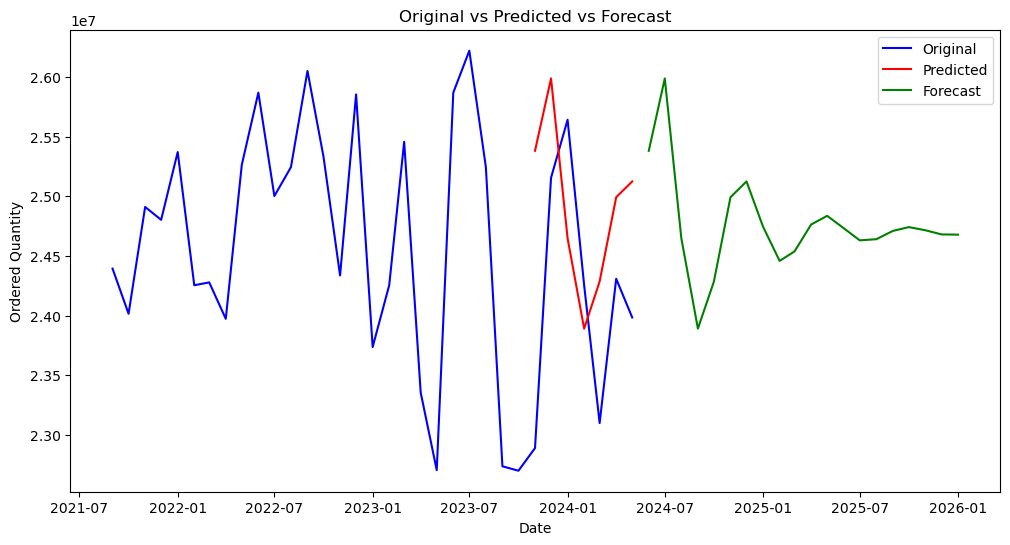

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Décomposer la série saisonnière
decomposition = seasonal_decompose(df_log)

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle ARIMA sur l'ensemble d'apprentissage
model = ARIMA(train_data, order=(2, 0,3))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Convertir les prédictions en antilogarithme
predictions_antilog = np.exp(predictions)

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions_antilog)
mse = mean_squared_error(test_data, predictions_antilog)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions_antilog)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.forecast(steps=20)
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'DS'

# Afficher le DataFrame avec les prédictions en antilogarithme et la colonne "type"
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, np.exp(df_log['ordered_quantity']), label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions_antilog, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df['Date'], forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [43]:
################################    modele a retenir #########################################

C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 0.036563119112402474
MSE: 0.0016009659025515706
RMSE: 0.040012071960241834
R²: -0.09834666044032825
            lower ordered_quantity  upper ordered_quantity   Forecast type
2024-06-01               16.950836               17.078589  17.014712   DS
2024-07-01               16.933426               17.075495  17.004461   DS
2024-08-01               16.940996               17.080508  17.010752   DS
2024-09-01               16.915118               17.057072  16.986095   DS
2024-10-01               16.918208               17.065199  16.991704   DS
2024-11-01               16.906111               17.053471  16.979791   DS
2024-12-01               16.940217               17.088575  17.014396   DS
2025-01-01               16.954574               17.106709  17.030641   DS
2025-02-01               16.928937               17.078057  17.003497   DS
2025-03-01               16.940888               17.091063  17.015976   DS
2025-04-01               16.973370               17.123374  17.048372 

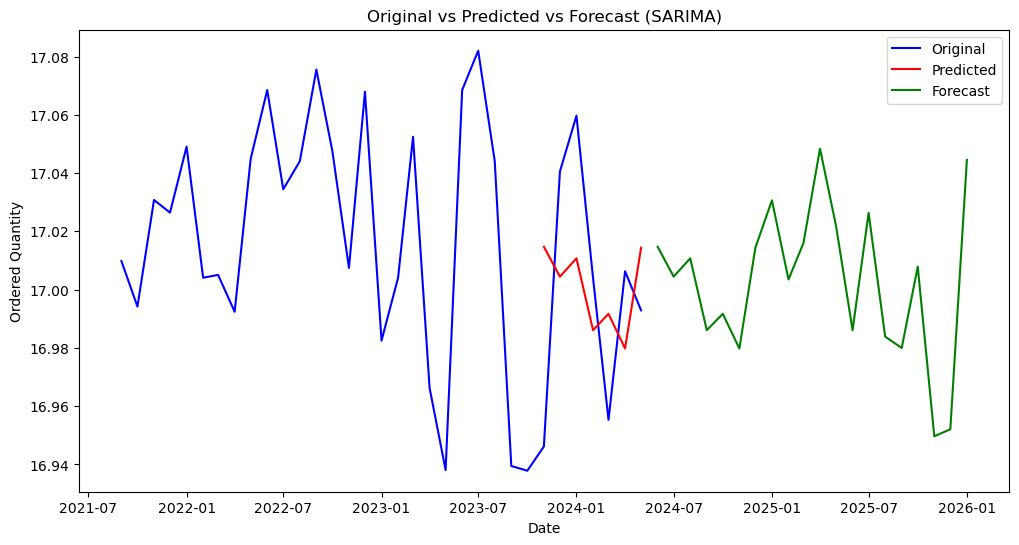

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Supposons que df_log est votre DataFrame contenant les données

# Convertir l'index en DatetimeIndex si nécessaire
df_log.index = pd.to_datetime(df_log.index)

# Rééchantillonner les données pour obtenir une fréquence mensuelle tout en gardant les valeurs d'origine
df_log = df_log.resample('MS').mean()

# Remplir les valeurs manquantes avec la méthode d'interpolation
df_log = df_log.interpolate(method='linear')

# Définir la proportion de données à utiliser pour l'apprentissage
train_size = 0.8  # 70% des données pour l'apprentissage
split_index = int(len(df_log) * train_size)

# Diviser les données en ensembles d'apprentissage et de test
train_data = df_log.iloc[:split_index]
test_data = df_log.iloc[split_index:]

# Créer et ajuster le modèle SARIMA sur l'ensemble d'apprentissage
# (p,d,q) x (P,D,Q,s) où s est la périodicité saisonnière, par exemple 12 pour les données mensuelles
model = SARIMAX(train_data, order=(4, 0, 4), seasonal_order=(4, 0, 4, 12))
results = model.fit()

# Effectuer des prédictions sur l'ensemble de test
predictions = results.predict(start=test_data.index[0], end=test_data.index[-1])

# Calcul des métriques d'évaluation
mae = mean_absolute_error(test_data, predictions)
mse = mean_squared_error(test_data, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_data, predictions)

# Afficher les métriques
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'R²: {r2}')

# Prédire les 20 mois à venir
forecast = results.get_forecast(steps=20)
forecast_df = forecast.conf_int()
forecast_df['Forecast'] = forecast.predicted_mean

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_df.index = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'DS'

# Afficher le DataFrame avec les prédictions
print(forecast_df)

# Tracer les courbes
plt.figure(figsize=(12, 6))

# Courbe de la série originale
plt.plot(df_log.index, df_log['ordered_quantity'], label='Original', color='blue')

# Courbe des prédictions
plt.plot(test_data.index, predictions, label='Predicted', color='red')

# Courbe des prévisions futures
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='green')

# Ajouter des légendes et des titres
plt.title('Original vs Predicted vs Forecast (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Ordered Quantity')
plt.legend()

# Afficher la courbe
plt.show()


In [56]:



import pyodbc
import pandas as pd
import numpy as np
import pyodbc



# Convertir les prédictions en DataFrame avec les dates appropriées
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast})
print(forecast_df)


# Prédire les 12 mois à venir
forecast = results.forecast(steps=20)

print(forecast)

# Convertir les prédictions en antilogarithme
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "DSL"
forecast_df['type'] = 'DS'

# Afficher le DataFrame avec les prédictions en antilogarithme et la colonne "type"
print(forecast_df)





# Définir les informations de connexion
server = 'LAPTOP-HED7JE2F'
database = 'PGS_STAGE_DW'
username = 'sa'
password = 'sa@123@123'

# Établir la connexion
conn = pyodbc.connect('DRIVER={SQL Server};SERVER='+server+';DATABASE='+database+';UID='+username+';PWD='+password)
print("Connexion réussie à la base de données SQL Server")

# Créer un curseur
cursor = conn.cursor()

# Vérifier si la table de sauvegarde existe
cursor.execute("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_NAME = 'dim_pred_orders_ds_backup'")
backup_table_exists = cursor.fetchone()[0]

if backup_table_exists:
    # Supprimer la table de sauvegarde existante
    cursor.execute("DROP TABLE dim_pred_orders_ds_backup")
    print("Ancienne table de sauvegarde supprimée avec succès.")

# Vérifier si la table principale existe
cursor.execute("SELECT COUNT(*) FROM INFORMATION_SCHEMA.TABLES WHERE TABLE_NAME = 'dim_pred_orders_ds'")
table_exists = cursor.fetchone()[0]

if table_exists:
    # Créer une nouvelle table de sauvegarde avec le suffixe "_backup"
    backup_table_query = '''
    SELECT * INTO dim_pred_orders_ds_backup FROM dim_pred_orders_ds
    '''
    cursor.execute(backup_table_query)
    print("Table de sauvegarde créée avec succès.")

    # Supprimer l'ancienne table
    cursor.execute("DROP TABLE dim_pred_orders_ds")
    print("Ancienne table supprimée avec succès.")

# Créer une nouvelle table dim_pred_orders_test_back
create_table_query = '''
CREATE TABLE dim_pred_orders_ds (
    Date DATE,
    Forecast FLOAT,
    type NVARCHAR(50),
    PRIMARY KEY (Date, Forecast, type)
)
''' 
cursor.execute(create_table_query)
print("Nouvelle table créée avec succès.")

# Commit les changements
conn.commit()



# Convertir les prédictions en antilogarithme (j'ai supposé que vous avez la variable forecast déjà définie)
forecast_antilog = np.exp(forecast)

# Créer un DataFrame avec les dates appropriées et les valeurs prédites
forecast_dates = pd.date_range(start=df_log.index[-1], periods=21, freq='MS')[1:]
forecast_df = pd.DataFrame({'Date': forecast_dates, 'Forecast': forecast_antilog})

# Ajouter une colonne "type" au DataFrame avec la valeur "DS"
forecast_df['type'] = 'DS'

# Liste des tuples contenant les données à insérer
data_to_insert = [tuple(row) for row in forecast_df.values]

# Requête d'insertion de données
insert_query = '''
INSERT INTO dim_pred_orders_ds (Date, Forecast, type)
VALUES (?, ?, ?)
'''

# Exécuter la requête d'insertion de données pour chaque tuple
cursor.executemany(insert_query, data_to_insert)

# Valider les modifications
conn.commit()

# Fermer la connexion
conn.close()

print("Les données ont été insérées avec succès dans la table dim_pred_orders_ds.")


         Date                                           Forecast
0  2024-06-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
1  2024-07-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
2  2024-08-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
3  2024-09-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
4  2024-10-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
5  2024-11-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
6  2024-12-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
7  2025-01-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
8  2025-02-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
9  2025-03-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
10 2025-04-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
11 2025-05-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
12 2025-06-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
13 2025-07-01  <statsmodels.tsa.statespace.mlemodel.Predictio...
14 2025-08-01  <statsmode